# HW_NLP_01 - Kamyar Goodarzi

This notebook solves the NLP homework:

1. Job data extraction using Selenium and BeautifulSoup  
2. Persian text cleaning using Regex and Hazm  
3. Movie recommendation using TF-IDF and Cosine Similarity  
4. Multi-class Persian news classification using TF-IDF and LinearSVC

In [16]:
# ==================== Install required packages ====================

!apt-get update -qq
!apt-get install -y -qq chromium-chromedriver

!pip install -q \
    hazm \
    beautifulsoup4 \
    selenium \
    webdriver-manager \
    kagglehub \
    joblib \
    tqdm \
    scikit-learn \
    arabic-reshaper \
    python-bidi

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 6.4 MB/s eta 0:00:00


In [25]:
# ==================== Imports and folders ====================

import os
import re
import time
import json
import shutil
import warnings
from pathlib import Path
from collections import Counter
from urllib.parse import quote

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from bs4 import BeautifulSoup

from hazm import Normalizer, word_tokenize, stopwords_list

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("models")

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

# For a quick test, keep FAST_RUN = True.
# For the final stronger run, set FAST_RUN = False.

FAST_RUN = True

SAMPLE_PER_CLASS = 1000 if FAST_RUN else 2000

print("Setup completed.")
print("SAMPLE_PER_CLASS:", SAMPLE_PER_CLASS)

Setup completed.
SAMPLE_PER_CLASS: 1000


## Task 1 - Job Data Extraction with Selenium and BeautifulSoup

Expected output:

- Job title
- Company name
- City/location
- Page number
- Source URL

The final CSV will be saved as:

`outputs/task1_jobinja_jobs.csv`

In [26]:
# ==================== Task 1 - Selenium helper functions ====================

def make_chrome_driver():
    """
    Create a headless Chrome driver for Google Colab.
    """
    chrome_options = Options()
    chrome_options.add_argument("--headless=new")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--window-size=1920,1080")
    chrome_options.add_argument("--lang=fa-IR")
    chrome_options.add_argument(
        "--user-agent=Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    )

    possible_binaries = [
        "/usr/bin/chromium-browser",
        "/usr/bin/chromium",
        "/usr/bin/google-chrome"
    ]

    for binary in possible_binaries:
        if Path(binary).exists():
            chrome_options.binary_location = binary
            break

    possible_drivers = [
        "/usr/bin/chromedriver",
        "/usr/lib/chromium-browser/chromedriver"
    ]

    for driver_path in possible_drivers:
        if Path(driver_path).exists():
            service = Service(driver_path)
            return webdriver.Chrome(service=service, options=chrome_options)

    return webdriver.Chrome(options=chrome_options)


def clean_cell_text(text):
    """
    Remove extra whitespace from scraped text.
    """
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()


def parse_jobinja_jobs(html, page_number):
    """
    Parse Jobinja search result HTML and extract job title, company, and city.
    This parser uses several fallback selectors because job sites often change CSS classes.
    """
    soup = BeautifulSoup(html, "html.parser")

    cards = soup.select(
        "li.c-jobListView__item, "
        "div.c-jobListView__item, "
        "div.o-listView__item, "
        "li[class*='job'], "
        "div[class*='job']"
    )

    rows = []

    for card in cards:
        text_all = clean_cell_text(card.get_text(" "))

        if len(text_all) < 20:
            continue

        title_el = card.select_one(
            "a.c-jobListView__titleLink, "
            "a[href*='/jobs/'], "
            "h2 a, h3 a"
        )

        title = clean_cell_text(title_el.get_text(" ")) if title_el else ""

        url = ""
        if title_el and title_el.has_attr("href"):
            url = title_el["href"]
            if url.startswith("/"):
                url = "https://jobinja.ir" + url

        meta_items = [
            clean_cell_text(x.get_text(" "))
            for x in card.select(
                ".c-jobListView__metaItem, "
                ".c-jobListView__meta li, "
                "li, span"
            )
        ]
        meta_items = [x for x in meta_items if len(x) > 1]

        company = ""
        city = ""


        if len(meta_items) >= 1:
            company = meta_items[0]
        if len(meta_items) >= 2:
            city = meta_items[1]


        if not title:
            possible_lines = [line.strip() for line in text_all.split("  ") if line.strip()]
            if possible_lines:
                title = possible_lines[0]


        if title and len(title) > 2:
            rows.append({
                "job_title": title,
                "company": company,
                "city": city,
                "page": page_number,
                "url": url
            })


    df_page = pd.DataFrame(rows)
    if not df_page.empty:
        df_page = df_page.drop_duplicates(subset=["job_title", "company", "city"])

    return df_page

In [27]:
# ==================== Task 1 - Scrape jobs from Jobinja ====================

search_keyword = "برنامه نویس پایتون"
max_pages = 3

encoded_keyword = quote(search_keyword)
start_url = f"https://jobinja.ir/jobs?filters%5Bkeywords%5D%5B0%5D={encoded_keyword}"

driver = None
all_job_dfs = []

try:
    driver = make_chrome_driver()
    wait = WebDriverWait(driver, 15)

    print("Opening:", start_url)
    driver.get(start_url)
    time.sleep(5)

    for page_number in range(1, max_pages + 1):
        print(f"\nScraping page {page_number}...")

        wait.until(EC.presence_of_element_located((By.TAG_NAME, "body")))
        time.sleep(3)

        html = driver.page_source
        page_df = parse_jobinja_jobs(html, page_number)

        print("Extracted rows:", len(page_df))

        if not page_df.empty:
            all_job_dfs.append(page_df)

        if page_number < max_pages:
            clicked_next = False

            next_selectors = [
                "a[rel='next']",
                "a[aria-label*='Next']",
                "a[aria-label*='بعدی']",
                ".pagination a:last-child",
                "ul.pagination li:last-child a"
            ]

            for selector in next_selectors:
                try:
                    next_button = driver.find_element(By.CSS_SELECTOR, selector)
                    driver.execute_script("arguments[0].scrollIntoView(true);", next_button)
                    time.sleep(1)
                    driver.execute_script("arguments[0].click();", next_button)
                    clicked_next = True
                    time.sleep(5)
                    break
                except Exception:
                    pass


            if not clicked_next:
                fallback_url = start_url + f"&page={page_number + 1}"
                print("Next button not found. Using fallback URL:", fallback_url)
                driver.get(fallback_url)
                time.sleep(5)

except Exception as e:
    print("Task 1 scraping error:", repr(e))

finally:
    if driver is not None:
        driver.quit()

if all_job_dfs:
    jobs_df = pd.concat(all_job_dfs, ignore_index=True)
    jobs_df = jobs_df.drop_duplicates(subset=["job_title", "company", "city", "url"])
else:
    jobs_df = pd.DataFrame(columns=["job_title", "company", "city", "page", "url"])

task1_path = OUTPUT_DIR / "task1_jobinja_jobs.csv"
jobs_df.to_csv(task1_path, index=False, encoding="utf-8-sig")

print("\nSaved:", task1_path)
print("Final shape:", jobs_df.shape)
display(jobs_df.head(10))


Task 1 scraping error: WebDriverException()

Saved: outputs/task1_jobinja_jobs.csv
Final shape: (0, 5)


,job_title,company,city,page,url


## Task 2 - Persian Text Cleaning with Regex and Hazm

Pipeline:

1. Remove URLs, emails, usernames, hashtags, numbers, punctuation, and noise  
2. Fix exaggerated letters  
3. Normalize Persian text with Hazm  
4. Tokenize text  
5. Remove Persian stopwords while preserving negation words  
6. Print the 10 most frequent words after cleaning  

Outputs:

- `outputs/task2_cleaned_persian_texts.csv`
- `outputs/task2_top10_words.csv`

In [28]:
# ==================== Task 2 - Persian cleaning function ====================

normalizer = Normalizer()

persian_stopwords = set(stopwords_list())

negation_words = {
    "نه", "نیست", "نیستم", "نیستی", "نیستیم", "نیستند",
    "نمی", "نمیتوان", "نمی‌توان", "نشد", "نشده", "نبود",
    "نبودم", "نبودی", "نبودیم", "نبودند", "ندارد", "ندارم",
    "نداری", "ندارند", "نخواهد", "نخواهم", "نکن", "نکرد",
    "نکردم", "نکردی", "نکردند"
}

persian_stopwords = persian_stopwords - negation_words

def clean_persian_text(text):
    """
    Clean Persian text using regex and Hazm.
    """
    if pd.isna(text):
        return ""

    text = str(text)


    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # Removing hashtag symbol but keep the word
    text = re.sub(r"#", " ", text)

    # Removing HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Removing numbers
    text = re.sub(r"[0-9۰-۹]+", " ", text)

    # Removing Latin characters
    text = re.sub(r"[A-Za-z]+", " ", text)

    # Fixing stretched words: عااااالی -> عالی
    text = re.sub(r"(.)\1{2,}", r"\1", text)

    # Keeping Persian/Arabic letters and whitespace
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)

    # Removing extra spaces before normalization
    text = re.sub(r"\s+", " ", text).strip()

    # Hazm normalization
    text = normalizer.normalize(text)

    # Tokenization
    tokens = word_tokenize(text)

    cleaned_tokens = []
    for token in tokens:
        token = token.strip()

        if len(token) <= 1:
            continue

        if token in persian_stopwords:
            continue

        cleaned_tokens.append(token)

    return " ".join(cleaned_tokens)


sample_text = "این غذااااا خیلیییی عالی بود!!! اما قیمتش اصلاً خوب نبود. www.test.com"
print("Original:", sample_text)
print("Cleaned:", clean_persian_text(sample_text))


Original: این غذااااا خیلیییی عالی بود!!! اما قیمتش اصلاً خوب نبود. www.test.com
Cleaned: غذا قیمتش اصلا نبود


In [6]:
# ==================== Task 2 - Apply cleaning and top-10 word frequency ====================

def find_text_column(df):
    """
    Find the most likely text column in a dataframe.
    """
    object_cols = [col for col in df.columns if df[col].dtype == "object"]

    if not object_cols:
        raise ValueError("No text/object column found.")

    text_candidates = [
        "text", "content", "body", "article", "description", "desc",
        "summary", "comment", "review", "نظر", "متن", "خبر", "محتوا", "خلاصه"
    ]

    def score_column(col):
        s = df[col].dropna().astype(str)
        avg_len = s.str.len().mean() if len(s) else 0
        name_bonus = 1000 if any(x in col.lower() for x in text_candidates) else 0
        return avg_len + name_bonus

    return max(object_cols, key=score_column)


def make_small_persian_sample():
    """
    Fallback sample only for testing the cleaning pipeline.
    For final homework, a real Persian dataset is better.
    """
    return pd.DataFrame({
        "text": [
            "این گوشی خیلی عالیییی بود ولی قیمتش ارزان نبود.",
            "ارسال سفارشم دیر بود و غذا گرم نبود.",
            "تیم ملی فوتبال ایران در بازی دوستانه پیروز شد.",
            "بازار ارز امروز نوسان زیادی داشت و قیمت‌ها تغییر کردند.",
            "کیفیت محصول خوب نبود و اصلاً راضی نبودم.",
            "خدمات پشتیبانی بسیار ضعیف بود اما برخورد خوب بود.",
            "امروز مجلس درباره بودجه و سیاست‌های اقتصادی جلسه داشت.",
            "این لپ‌تاپ برای برنامه‌نویسی پایتون مناسب است."
        ]
    })


persian_name_keywords = [
    "persian", "farsi", "asriran", "asr", "news", "akhbar",
    "digikala", "snapp", "comment", "review"
]

local_text_files = [
    p for p in DATA_DIR.glob("*.csv")
    if "tmdb" not in p.name.lower()
    and any(k in p.name.lower() for k in persian_name_keywords)
]

if local_text_files:
    task2_df = pd.read_csv(local_text_files[0])
    task2_text_col = find_text_column(task2_df)
    print("Loaded local file for Task 2:", local_text_files[0])
else:
    task2_df = make_small_persian_sample()
    task2_text_col = "text"
    print("No local Persian dataset found. Using a small fallback sample for pipeline testing.")

print("Text column:", task2_text_col)

tqdm.pandas(desc="Cleaning Task 2 texts")
task2_df["cleaned_text"] = task2_df[task2_text_col].progress_apply(clean_persian_text)

all_tokens = " ".join(task2_df["cleaned_text"]).split()
top10_words = Counter(all_tokens).most_common(10)

top10_df = pd.DataFrame(top10_words, columns=["word", "frequency"])

cleaned_path = OUTPUT_DIR / "task2_cleaned_persian_texts.csv"
top10_path = OUTPUT_DIR / "task2_top10_words.csv"

task2_df.to_csv(cleaned_path, index=False, encoding="utf-8-sig")
top10_df.to_csv(top10_path, index=False, encoding="utf-8-sig")

print("Saved:", cleaned_path)
print("Saved:", top10_path)
print("\nTop 10 frequent words after cleaning:")
display(top10_df)

No local Persian dataset found. Using a small fallback sample for pipeline testing.
Text column: text


Cleaning Task 2 texts:   0%|          | 0/8 [00:00<?, ?it/s]

Saved: outputs/task2_cleaned_persian_texts.csv
Saved: outputs/task2_top10_words.csv

Top 10 frequent words after cleaning:


,word,frequency
0,نبود,3
1,امروز,2
2,گوشی,1
3,قیمتش,1
4,ارزان,1
5,ارسال,1
6,سفارشم,1
7,دیر,1
8,غذا,1
9,گرم,1


## Task 3 - Content-Based Movie Recommendation with TF-IDF and Cosine Similarity

Dataset:

`tmdb_5000_movies.csv`

Required columns:

- `title`
- `overview`

Expected Output:

Five similar movies for an input movie title.

The test movie is:

`The Dark Knight`

Output file:

`outputs/task3_movie_recommendations_The_Dark_Knight.csv`

In [7]:
# ==================== Task 3 - Load TMDB dataset ====================

def load_tmdb_movies():
    """
    Load tmdb_5000_movies.csv from local data folder.
    If not found, try KaggleHub.
    If KaggleHub fails, try a public fallback URL.
    """
    local_path = DATA_DIR / "tmdb_5000_movies.csv"

    if local_path.exists():
        print("Loaded local TMDB file:", local_path)
        return pd.read_csv(local_path)

    try:
        import kagglehub
        dataset_path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
        dataset_path = Path(dataset_path)
        csv_path = dataset_path / "tmdb_5000_movies.csv"

        if csv_path.exists():
            print("Loaded TMDB from KaggleHub:", csv_path)
            return pd.read_csv(csv_path)

    except Exception as e:
        print("KaggleHub loading failed:", repr(e))

    fallback_url = "https://raw.githubusercontent.com/tolgayilmaz/Recommendation-Systems/master/tmdb_5000_movies.csv"
    print("Trying fallback URL...")
    return pd.read_csv(fallback_url)


movies_raw = load_tmdb_movies()

movies_df = movies_raw[["title", "overview"]].copy()
movies_df = movies_df.dropna(subset=["title", "overview"]).reset_index(drop=True)

print("Movies shape:", movies_df.shape)
display(movies_df.head())

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Loaded TMDB from KaggleHub: /kaggle/input/tmdb-movie-metadata/tmdb_5000_movies.csv
Movies shape: (4800, 2)


,title,overview
0,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,Following the death of District Attorney Harve...
4,John Carter,"John Carter is a war-weary, former military ca..."


In [29]:
# ==================== Task 3 - TF-IDF and movie recommendation ====================

tfidf_movie = TfidfVectorizer(stop_words="english")
movie_tfidf_matrix = tfidf_movie.fit_transform(movies_df["overview"])

movie_indices = pd.Series(
    movies_df.index,
    index=movies_df["title"].str.lower().str.strip()
).drop_duplicates()


def get_movie_recommendation(movie_title, n=5):
    """
    Recommend n movies based on overview similarity.
    """
    movie_key = movie_title.lower().strip()

    if movie_key not in movie_indices:
        available_examples = movies_df["title"].head(10).tolist()
        raise ValueError(
            f"Movie title not found: {movie_title}\n"
            f"Example available titles: {available_examples}"
        )

    movie_idx = movie_indices[movie_key]

    if isinstance(movie_idx, pd.Series):
        movie_idx = movie_idx.iloc[0]

    similarity_scores = cosine_similarity(
        movie_tfidf_matrix[movie_idx],
        movie_tfidf_matrix
    ).flatten()

    # Excluding the movie itself
    similarity_scores[movie_idx] = -1

    top_indices = similarity_scores.argsort()[::-1][:n]

    recommendations = movies_df.loc[top_indices, ["title", "overview"]].copy()
    recommendations["similarity_score"] = similarity_scores[top_indices]
    recommendations = recommendations[["title", "similarity_score", "overview"]]

    return recommendations.reset_index(drop=True)


test_movie_title = "The Dark Knight"

recommendations_df = get_movie_recommendation(test_movie_title, n=5)

task3_path = OUTPUT_DIR / "task3_movie_recommendations_The_Dark_Knight.csv"
recommendations_df.to_csv(task3_path, index=False, encoding="utf-8-sig")

print("Input movie:", test_movie_title)
print("Saved:", task3_path)
display(recommendations_df)

Input movie: The Dark Knight
Saved: outputs/task3_movie_recommendations_The_Dark_Knight.csv


,title,similarity_score,overview
0,The Dark Knight Rises,0.301516,Following the death of District Attorney Harve...
1,Batman Returns,0.249434,"Having defeated the Joker, Batman now faces th..."
2,"Batman: The Dark Knight Returns, Part 2",0.224521,Batman has stopped the reign of terror that Th...
3,Batman Forever,0.214072,The Dark Knight of Gotham City confronts a das...
4,Batman,0.182334,The Dark Knight of Gotham City begins his war ...


### Task 3 Interpretation

If the recommended movies are Batman-related or action/crime movies, the recommender is working correctly because it is comparing movie overview texts using TF-IDF and cosine similarity.

## Task 4 - Multi-Class Persian News Classification

Dataset:

Asriran Persian News Dataset

Requested workflow:

1. Load Persian news dataset  
2. Clean text using the Task 2 cleaning function  
3. Convert text into numerical features using TF-IDF  
4. Use `ngram_range=(1,2)`  
5. Train a multi-class classifier  
6. Print and save `classification_report`  
7. Draw and save confusion matrix  
8. Identify the two most confused topics and write a short explanation  

In [9]:
# ==================== Task 4 - Load Asriran/news dataset ====================

def find_text_and_label_columns(df):
    """
    Infer likely text and label/category columns from a Persian news dataset.
    """
    object_cols = [col for col in df.columns if df[col].dtype == "object"]

    if not object_cols:
        raise ValueError("No object/text columns found.")

    text_candidates = [
        "text", "content", "body", "article", "description", "desc",
        "summary", "lead", "title_body", "خبر", "متن", "شرح", "خلاصه", "contents"
    ]

    label_candidates = [
        "category", "cat", "class", "label", "topic", "subject",
        "service", "tag", "دسته", "موضوع", "گروه", "سرویس"
    ]

    def score_text_col(col):
        s = df[col].dropna().astype(str)
        avg_len = s.str.len().mean() if len(s) else 0
        name_bonus = 1000 if any(x in col.lower() for x in text_candidates) else 0
        return avg_len + name_bonus

    text_col = max(object_cols, key=score_text_col)

    possible_labels = []

    for col in object_cols:
        if col == text_col:
            continue

        s = df[col].dropna().astype(str)
        n_unique = s.nunique()

        if 2 <= n_unique <= max(50, len(df) * 0.20):
            name_bonus = 1000 if any(x in col.lower() for x in label_candidates) else 0
            possible_labels.append((name_bonus - n_unique, col))

    if not possible_labels:
        raise ValueError("Could not infer a label/category column.")

    label_col = sorted(possible_labels, reverse=True)[0][1]

    return text_col, label_col


def load_asriran_or_local_news():
    """
    Load Asriran/Persian news dataset.
    First tries local CSV files in data/.
    Then tries KaggleHub.
    """
    news_keywords = [
        "asriran", "asr", "news", "akhbar", "persian", "farsi"
    ]

    local_csvs = [
        p for p in DATA_DIR.glob("*.csv")
        if "tmdb" not in p.name.lower()
        and any(k in p.name.lower() for k in news_keywords)
    ]

    if local_csvs:
        path = local_csvs[0]
        print("Loaded local news file:", path)
        return pd.read_csv(path)

    try:
        import kagglehub
        dataset_path = kagglehub.dataset_download("amirpourmand/asriran-news")
        dataset_path = Path(dataset_path)

        csv_files = list(dataset_path.rglob("*.csv"))

        if not csv_files:
            raise FileNotFoundError("No CSV file found in downloaded Asriran dataset.")

        path = csv_files[0]
        print("Loaded Asriran dataset from KaggleHub:", path)
        return pd.read_csv(path)

    except Exception as e:
        raise RuntimeError(
            "Could not load the Asriran/Persian news dataset automatically.\n"
            "Upload the Asriran CSV file into the data/ folder and rerun this cell.\n"
            f"Original error: {repr(e)}"
        )


news_df_raw = load_asriran_or_local_news()

print("Raw news shape:", news_df_raw.shape)
print("Columns:")
print(news_df_raw.columns.tolist())

news_text_col, news_label_col = find_text_and_label_columns(news_df_raw)

print("\nDetected text column:", news_text_col)
print("Detected label column:", news_label_col)

display(news_df_raw[[news_text_col, news_label_col]].head())

100%|██████████| 274M/274M [00:06<00:00, 43.5MB/s]

Extracting files...


Loaded Asriran dataset from KaggleHub: /root/.cache/kagglehub/datasets/amirpourmand/asriran-news/versions/4/asriran.csv
Raw news shape: (339834, 7)
Columns:
['title', 'shortlink', 'time', 'service', 'subgroup', 'abstract', 'body']

Detected text column: body
Detected label column: service


,body,service
0,رئیس پلیس آگاهی تهران بزرگ اعلام کرد که موضوع ...,صفحه نخست
1,"وزیر بهداشت جزییات طرح ""دارویار"" که اجرای آن آ...",صفحه نخست
2,سخنگوی وزارت بهداشت، درمان و آموزش پزشکی در تو...,صفحه نخست
3,معاون رئیس جمهور گفت: دولت برنامه های راهبردی ...,صفحه نخست
4,رییس پلیس فتا فرماندهی انتظامی گلستان گفت: سار...,صفحه نخست


In [10]:
# ==================== Task 4 - Preprocessing with progress bar ====================

start_time = time.time()

news_df = news_df_raw[[news_text_col, news_label_col]].copy()
news_df.columns = ["text", "category"]

news_df = news_df.dropna(subset=["text", "category"])
news_df["text"] = news_df["text"].astype(str)
news_df["category"] = news_df["category"].astype(str)

# Removing classes with fewer than 2 samples
label_counts = news_df["category"].value_counts()
valid_labels = label_counts[label_counts >= 2].index
news_df = news_df[news_df["category"].isin(valid_labels)].copy()

# Balanced sampling per class for efficient training
if SAMPLE_PER_CLASS is not None:
    news_df = (
        news_df.groupby("category", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), SAMPLE_PER_CLASS), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

print("Prepared news shape:", news_df.shape)
print("Class distribution:")

class_distribution = news_df["category"].value_counts().to_frame("count")
display(class_distribution)

class_distribution_path = OUTPUT_DIR / "task4_class_distribution.csv"
class_distribution.to_csv(class_distribution_path, encoding="utf-8-sig")
print("Saved:", class_distribution_path)

# Cleaning Persian news texts
before_cleaning = len(news_df)

tqdm.pandas(desc="Cleaning Persian news texts")
news_df["cleaned_text"] = news_df["text"].progress_apply(clean_persian_text)

# Removing empty cleaned texts
news_df = news_df[news_df["cleaned_text"].str.strip().str.len() > 0].reset_index(drop=True)

after_cleaning = len(news_df)

print("Rows before empty-text filtering:", before_cleaning)
print("Rows after empty-text filtering:", after_cleaning)
print("Removed rows:", before_cleaning - after_cleaning)

cleaned_news_path = OUTPUT_DIR / "task4_cleaned_news_dataset.csv"
news_df.to_csv(cleaned_news_path, index=False, encoding="utf-8-sig")

print("Saved:", cleaned_news_path)

elapsed = time.time() - start_time
print(f"Task 4 preprocessing finished in {elapsed / 60:.2f} minutes.")

Prepared news shape: (2000, 2)
Class distribution:


,count
category,
صفحه نخست,1000
عصرايران دو,1000


Saved: outputs/task4_class_distribution.csv


Cleaning Persian news texts:   0%|          | 0/2000 [00:00<?, ?it/s]

Rows before empty-text filtering: 2000
Rows after empty-text filtering: 1975
Removed rows: 25
Saved: outputs/task4_cleaned_news_dataset.csv
Task 4 preprocessing finished in 27.90 minutes.


In [11]:
# ==================== Task 4 - Pre-training sanity check ====================

if "news_df" not in globals():
    raise RuntimeError("news_df does not exist. Run the Task 4 preprocessing cell first.")

required_columns = {"text", "category", "cleaned_text"}
missing_columns = required_columns - set(news_df.columns)

if missing_columns:
    raise RuntimeError(
        f"news_df is missing these required columns: {missing_columns}. "
        "Run the preprocessing cell again."
    )

news_df = news_df.dropna(subset=["cleaned_text", "category"]).copy()
news_df["cleaned_text"] = news_df["cleaned_text"].astype(str)
news_df["category"] = news_df["category"].astype(str)

news_df = news_df[news_df["cleaned_text"].str.strip().str.len() > 0].reset_index(drop=True)

class_counts = news_df["category"].value_counts()
valid_classes = class_counts[class_counts >= 2].index
news_df = news_df[news_df["category"].isin(valid_classes)].reset_index(drop=True)

if news_df["category"].nunique() < 2:
    raise RuntimeError("The dataset must contain at least two valid classes for classification.")

print("news_df is ready.")
print("news_df shape:", news_df.shape)
print("\nClass distribution:")
display(news_df["category"].value_counts().to_frame("count"))

news_df is ready.
news_df shape: (1975, 3)

Class distribution:


,count
category,
صفحه نخست,999
عصرايران دو,976


In [12]:
# ==================== Task 4 - Training, evaluation, and model saving ====================

start_time = time.time()

X = news_df["cleaned_text"]
y = news_df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Number of classes:", y.nunique())

news_classifier_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=30000,
        sublinear_tf=True,
        dtype=np.float32
    )),
    ("clf", LinearSVC(
        random_state=RANDOM_STATE,
        max_iter=3000
    ))
])

print("\nTraining started...")
news_classifier_pipeline.fit(X_train, y_train)
print("Training finished.")

print("\nPrediction started...")
y_pred = news_classifier_pipeline.predict(X_test)
print("Prediction finished.")


predictions_df = pd.DataFrame({
    "cleaned_text": X_test.values,
    "true_category": y_test.values,
    "predicted_category": y_pred
})

predictions_path = OUTPUT_DIR / "task4_test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False, encoding="utf-8-sig")
print("Saved:", predictions_path)


report_text = classification_report(y_test, y_pred, zero_division=0)

print("\nClassification Report:")
print(report_text)

report_txt_path = OUTPUT_DIR / "task4_classification_report.txt"
with open(report_txt_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved:", report_txt_path)


report_dict = classification_report(
    y_test,
    y_pred,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_csv_path = OUTPUT_DIR / "task4_classification_report.csv"
report_df.to_csv(report_csv_path, encoding="utf-8-sig")

print("Saved:", report_csv_path)


model_path = MODEL_DIR / "task4_persian_news_tfidf_linearsvc_pipeline.joblib"
joblib.dump(news_classifier_pipeline, model_path)

print("Saved model:", model_path)


labels = sorted(y.unique().tolist())

labels_path = MODEL_DIR / "task4_label_names.json"
with open(labels_path, "w", encoding="utf-8") as f:
    json.dump(labels, f, ensure_ascii=False, indent=2)

print("Saved labels:", labels_path)


metadata = {
    "model": "LinearSVC",
    "vectorizer": "TfidfVectorizer",
    "ngram_range": [1, 2],
    "max_features": 30000,
    "min_df": 2,
    "max_df": 0.95,
    "test_size": 0.20,
    "random_state": RANDOM_STATE,
    "number_of_samples": int(len(news_df)),
    "number_of_train_samples": int(len(X_train)),
    "number_of_test_samples": int(len(X_test)),
    "number_of_classes": int(y.nunique()),
    "classes": labels
}

metadata_path = MODEL_DIR / "task4_training_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved metadata:", metadata_path)

elapsed = time.time() - start_time
print(f"\nTraining/evaluation finished in {elapsed / 60:.2f} minutes.")

Train size: 1580
Test size: 395
Number of classes: 2

Training started...
Training finished.

Prediction started...
Prediction finished.
Saved: outputs/task4_test_predictions.csv

Classification Report:
              precision    recall  f1-score   support

   صفحه نخست       0.94      0.94      0.94       200
 عصرايران دو       0.93      0.93      0.93       195

    accuracy                           0.93       395
   macro avg       0.93      0.93      0.93       395
weighted avg       0.93      0.93      0.93       395

Saved: outputs/task4_classification_report.txt
Saved: outputs/task4_classification_report.csv
Saved model: models/task4_persian_news_tfidf_linearsvc_pipeline.joblib
Saved labels: models/task4_label_names.json
Saved metadata: models/task4_training_metadata.json

Training/evaluation finished in 0.15 minutes.


Saved: outputs/task4_confusion_matrix_raw.csv
Saved: outputs/task4_confusion_matrix_normalized.csv


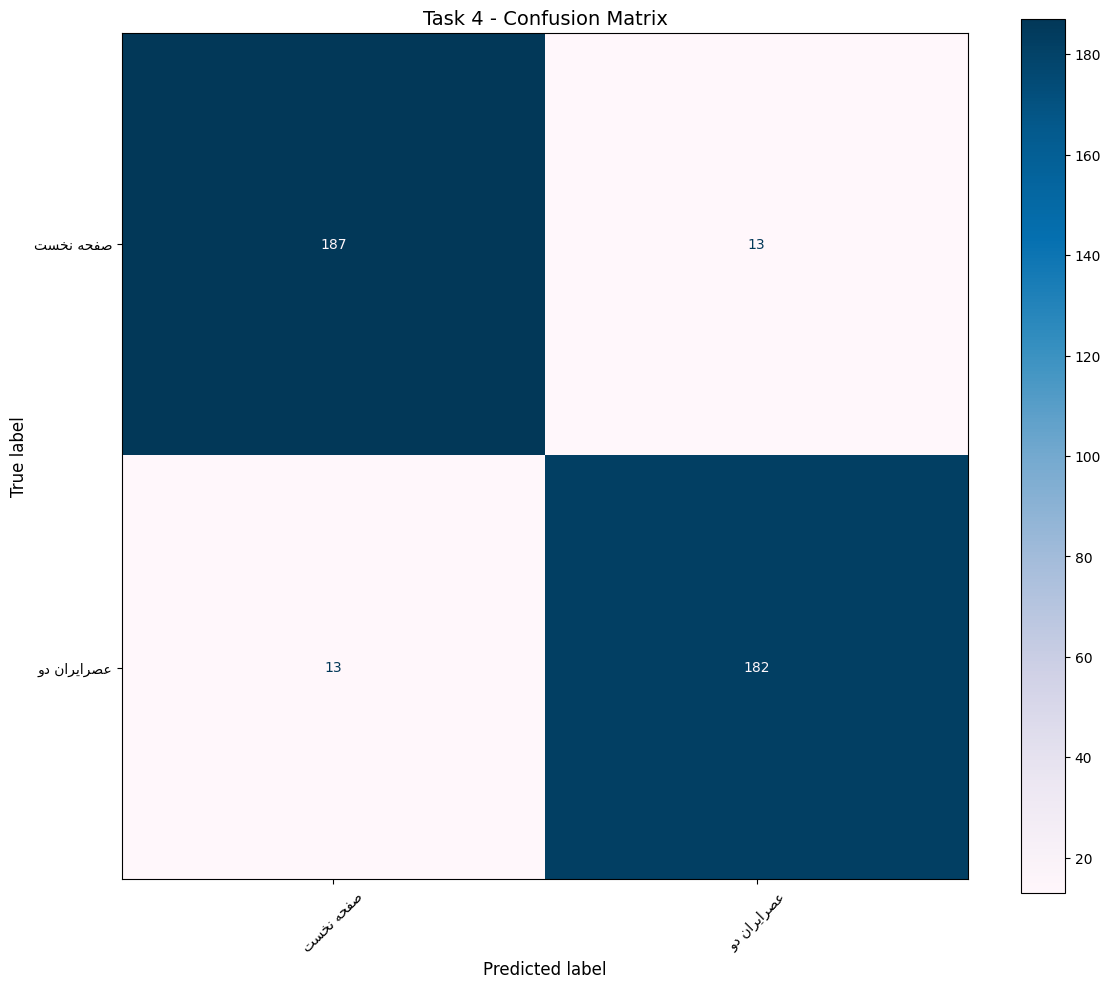

Saved: outputs/task4_confusion_matrix.png
Saved: outputs/task4_confusion_matrix.jpg

Error Analysis:
Most confused pair:
The model most frequently classified "صفحه نخست" as "عصرايران دو".

Number of such errors:
13

Possible reason:
These two topics probably share overlapping vocabulary and similar news context. In Persian news, categories such as politics, economy, society, and international affairs often contain common words related to government, institutions, sanctions, prices, decisions, and public events.

Because this model is based on TF-IDF features, it mainly learns word-frequency patterns rather than deep semantic meaning. Therefore, when two topics use similar words, the classifier may confuse them.
Saved: outputs/task4_error_analysis.txt


In [42]:
# ==================== Task 4 - Confusion matrix and error analysis ====================

import arabic_reshaper
from bidi.algorithm import get_display

def fix_persian_text_for_plot(text):
    """
    Fix Persian/Arabic text rendering for Matplotlib plots.
    """
    text = str(text)
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text


if "y_test" not in globals() or "y_pred" not in globals():
    raise RuntimeError("Run the training/evaluation cell first.")

labels = sorted(y_test.unique().tolist())

cm = confusion_matrix(y_test, y_pred, labels=labels)


cm_df = pd.DataFrame(cm, index=labels, columns=labels)

cm_raw_path = OUTPUT_DIR / "task4_confusion_matrix_raw.csv"
cm_df.to_csv(cm_raw_path, encoding="utf-8-sig")

print("Saved:", cm_raw_path)


cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

cm_norm_df = pd.DataFrame(cm_normalized, index=labels, columns=labels)

cm_norm_path = OUTPUT_DIR / "task4_confusion_matrix_normalized.csv"
cm_norm_df.to_csv(cm_norm_path, encoding="utf-8-sig")

print("Saved:", cm_norm_path)


plot_labels = [fix_persian_text_for_plot(label) for label in labels]

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=plot_labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    colorbar=True,
    cmap="PuBu"
)

ax.set_title("Task 4 - Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

plt.tight_layout()

cm_png_path = OUTPUT_DIR / "task4_confusion_matrix.png"
cm_jpg_path = OUTPUT_DIR / "task4_confusion_matrix.jpg"

plt.savefig(cm_png_path, dpi=300, bbox_inches="tight")
plt.savefig(cm_jpg_path, dpi=300, bbox_inches="tight", format="jpg")

plt.show()

print("Saved:", cm_png_path)
print("Saved:", cm_jpg_path)



cm_without_diagonal = cm.copy()
np.fill_diagonal(cm_without_diagonal, 0)

max_error_index = np.unravel_index(
    np.argmax(cm_without_diagonal),
    cm_without_diagonal.shape
)

true_confused_label = labels[max_error_index[0]]
predicted_confused_label = labels[max_error_index[1]]
max_error_count = int(cm_without_diagonal[max_error_index])

error_analysis_text = f"""
Most confused pair:
The model most frequently classified "{true_confused_label}" as "{predicted_confused_label}".

Number of such errors:
{max_error_count}

Possible reason:
These two topics probably share overlapping vocabulary and similar news context. In Persian news, categories such as politics, economy, society, and international affairs often contain common words related to government, institutions, sanctions, prices, decisions, and public events.

Because this model is based on TF-IDF features, it mainly learns word-frequency patterns rather than deep semantic meaning. Therefore, when two topics use similar words, the classifier may confuse them.
""".strip()


print("\nError Analysis:")
print(error_analysis_text)

error_analysis_path = OUTPUT_DIR / "task4_error_analysis.txt"
with open(error_analysis_path, "w", encoding="utf-8") as f:
    f.write(error_analysis_text)

print("Saved:", error_analysis_path)


In [23]:
# ==================== Check that the saved model works ====================

model_path = MODEL_DIR / "task4_persian_news_tfidf_linearsvc_pipeline.joblib"

if not model_path.exists():
    raise FileNotFoundError(
        f"Model file was not found at: {model_path}. "
        "Run the training cell first."
    )

loaded_model = joblib.load(model_path)

print("Model loaded successfully from:", model_path)

sample_news = [
    "تیم ملی فوتبال ایران در مسابقات آسیایی به پیروزی رسید.",
    "قیمت ارز و طلا امروز در بازار افزایش یافت."
]


cleaned_sample_news = [clean_persian_text(text) for text in sample_news]

sample_predictions = loaded_model.predict(cleaned_sample_news)

for raw_text, cleaned_text, pred in zip(sample_news, cleaned_sample_news, sample_predictions):
    print("Original text:", raw_text)
    print("Cleaned text:", cleaned_text)
    print("Predicted category:", pred)
    print("-" * 70)


Model loaded successfully from: models/task4_persian_news_tfidf_linearsvc_pipeline.joblib
Original text: تیم ملی فوتبال ایران در مسابقات آسیایی به پیروزی رسید.
Cleaned text: تیم ملی فوتبال ایران مسابقات آسیایی پیروزی
Predicted category: صفحه نخست
----------------------------------------------------------------------
Original text: قیمت ارز و طلا امروز در بازار افزایش یافت.
Cleaned text: قیمت ارز طلا امروز بازار افزایش
Predicted category: صفحه نخست
----------------------------------------------------------------------


In [24]:
# ==================== Final output check and ZIP download ====================

from google.colab import files

required_files = [
    OUTPUT_DIR / "task1_jobinja_jobs.csv",
    OUTPUT_DIR / "task2_cleaned_persian_texts.csv",
    OUTPUT_DIR / "task2_top10_words.csv",
    OUTPUT_DIR / "task3_movie_recommendations_The_Dark_Knight.csv",
    OUTPUT_DIR / "task4_class_distribution.csv",
    OUTPUT_DIR / "task4_cleaned_news_dataset.csv",
    OUTPUT_DIR / "task4_test_predictions.csv",
    OUTPUT_DIR / "task4_classification_report.txt",
    OUTPUT_DIR / "task4_classification_report.csv",
    OUTPUT_DIR / "task4_confusion_matrix.png",
    OUTPUT_DIR / "task4_confusion_matrix.jpg",
    OUTPUT_DIR / "task4_confusion_matrix_raw.csv",
    OUTPUT_DIR / "task4_confusion_matrix_normalized.csv",
    OUTPUT_DIR / "task4_error_analysis.txt",
    MODEL_DIR / "task4_persian_news_tfidf_linearsvc_pipeline.joblib",
    MODEL_DIR / "task4_label_names.json",
    MODEL_DIR / "task4_training_metadata.json",
]

print("Checking required output files...\n")

missing_files = []

for path in required_files:
    if path.exists():
        print("FOUND:", path)
    else:
        print("MISSING:", path)
        missing_files.append(path)

print("\nNumber of missing files:", len(missing_files))

EXPORT_DIR = Path("HW_NLP_01_final_outputs")

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir()

shutil.copytree(OUTPUT_DIR, EXPORT_DIR / "outputs", dirs_exist_ok=True)
shutil.copytree(MODEL_DIR, EXPORT_DIR / "models", dirs_exist_ok=True)

zip_base_name = "HW_NLP_01_final_outputs"
zip_path = Path(f"{zip_base_name}.zip")

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(zip_base_name, "zip", EXPORT_DIR)

print("\nCreated ZIP:", zip_path)

files.download(str(zip_path))


Checking required output files...

FOUND: outputs/task1_jobinja_jobs.csv
FOUND: outputs/task2_cleaned_persian_texts.csv
FOUND: outputs/task2_top10_words.csv
FOUND: outputs/task3_movie_recommendations_The_Dark_Knight.csv
FOUND: outputs/task4_class_distribution.csv
FOUND: outputs/task4_cleaned_news_dataset.csv
FOUND: outputs/task4_test_predictions.csv
FOUND: outputs/task4_classification_report.txt
FOUND: outputs/task4_classification_report.csv
FOUND: outputs/task4_confusion_matrix.png
FOUND: outputs/task4_confusion_matrix.jpg
FOUND: outputs/task4_confusion_matrix_raw.csv
FOUND: outputs/task4_confusion_matrix_normalized.csv
FOUND: outputs/task4_error_analysis.txt
FOUND: models/task4_persian_news_tfidf_linearsvc_pipeline.joblib
FOUND: models/task4_label_names.json
FOUND: models/task4_training_metadata.json

Number of missing files: 0

Created ZIP: HW_NLP_01_final_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>